In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import tf_keras as keras
import math

https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [2]:
dataset_df = pd.read_csv("./data/final.csv")

In [3]:
dataset_df

,raceId,driverId,constructorId,grid,position,year,circuitId,date,time,circuitRef,driverRef
0,989,20,6,3.0,1.0,2018,1,2018-03-25,05:10:00,albert_park,vettel
1,989,1,131,1.0,2.0,2018,1,2018-03-25,05:10:00,albert_park,hamilton
2,989,8,6,2.0,3.0,2018,1,2018-03-25,05:10:00,albert_park,raikkonen
3,989,817,9,8.0,4.0,2018,1,2018-03-25,05:10:00,albert_park,ricciardo
4,989,4,1,10.0,5.0,2018,1,2018-03-25,05:10:00,albert_park,alonso
...,...,...,...,...,...,...,...,...,...,...,...
2774,1134,822,15,12.0,16.0,2024,11,2024-07-21,15:00,hungaroring,bottas
2775,1134,858,3,14.0,17.0,2024,11,2024-07-21,15:00,hungaroring,sargeant
2776,1134,839,214,19.0,18.0,2024,11,2024-07-21,15:00,hungaroring,ocon
2777,1134,855,15,18.0,19.0,2024,11,2024-07-21,15:00,hungaroring,zhou


In [10]:
training = dataset_df[dataset_df["year"] < 2021]
test = dataset_df[dataset_df["year"] >= 2021]

In [12]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(training, label="driverId")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test, label="driverId")

In [13]:
initial_model = tfdf.keras.RandomForestModel(verbose=2)

initial_model.fit(train_ds)

Use 8 thread(s) for training
Use /var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/tmprhhknnj3 as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'raceId': <tf.Tensor 'data:0' shape=(None,) dtype=int64>, 'constructorId': <tf.Tensor 'data_1:0' shape=(None,) dtype=int64>, 'grid': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'position': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'year': <tf.Tensor 'data_4:0' shape=(None,) dtype=int64>, 'circuitId': <tf.Tensor 'data_5:0' shape=(None,) dtype=int64>, 'date': <tf.Tensor 'data_6:0' shape=(None,) dtype=string>, 'time': <tf.Tensor 'data_7:0' shape=(None,) dtype=string>, 'circuitRef': <tf.Tensor 'data_8:0' shape=(None,) dtype=string>, 'driverRef': <tf.Tensor 'data_9:0' shape=(None,) dtype=string>}
Label: Tensor("data_10:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'raceId': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(

In [15]:
initial_model.compile(metrics=['accuracy'])
evaluation = initial_model.evaluate(test_ds, return_dict=True)
print()

for name, value in evaluation.items():
    print(f"{name}: {value:.4f}")

2/2 [==============================] - 2s 101ms/step - loss: 0.0000e+00 - accuracy: 0.6579

loss: 0.0000
accuracy: 0.6579


In [17]:
initial_model.save("./tmp/initial_model")

INFO:tensorflow:Assets written to: ./tmp/initial_model/assets


INFO:tensorflow:Assets written to: ./tmp/initial_model/assets


In [21]:
initial_model.summary()

Model: "random_forest_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (10):
	circuitId
	circuitRef
	constructorId
	date
	driverRef
	grid
	position
	raceId
	time
	year

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.     "driverRef"  0.476985 ################
    2. "constructorId"  0.304905 #######
    3.          "grid"  0.198033 ##
    4.          "date"  0.176648 #
    5.      "position"  0.162809 #
    6.        "raceId"  0.154400 
    7.          "year"  0.149851 
    8.    "circuitRef"  0.143973 
    9.          "time"  0.138158 
   10.     "circuitId"  0.137836 

Variable Importance: NUM_AS_ROOT:
    1.     "driverRef" 146.000000 ##############

In [22]:
initial_model.make_inspector().features()

["circuitId" (1; #1),
 "circuitRef" (4; #2),
 "constructorId" (1; #3),
 "date" (4; #4),
 "driverRef" (4; #5),
 "grid" (1; #6),
 "position" (1; #7),
 "raceId" (1; #8),
 "time" (4; #9),
 "year" (1; #10)]

In [23]:
initial_model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("driverRef" (4; #5), 0.47698518547312585),
  ("constructorId" (1; #3), 0.30490464861273453),
  ("grid" (1; #6), 0.19803252240175379),
  ("date" (4; #4), 0.1766478264613785),
  ("position" (1; #7), 0.16280942529900858),
  ("raceId" (1; #8), 0.15440020472850977),
  ("year" (1; #10), 0.14985148639516221),
  ("circuitRef" (4; #2), 0.14397265371831153),
  ("time" (4; #9), 0.13815818895039678),
  ("circuitId" (1; #1), 0.13783593383839984)],
 'NUM_AS_ROOT': [("driverRef" (4; #5), 146.0),
  ("constructorId" (1; #3), 80.0),
  ("grid" (1; #6), 51.0),
  ("position" (1; #7), 17.0),
  ("raceId" (1; #8), 3.0),
  ("date" (4; #4), 2.0),
  ("year" (1; #10), 1.0)],
 'SUM_SCORE': [("driverRef" (4; #5), 655516.8963788152),
  ("constructorId" (1; #3), 306493.55950219184),
  ("date" (4; #4), 49568.55128682684),
  ("grid" (1; #6), 40186.28588905372),
  ("raceId" (1; #8), 24416.894896276062),
  ("position" (1; #7), 20989.188594435283),
  ("year" (1; #10), 19676.429963178933),
  ("circ

In [24]:
initial_model.make_inspector().evaluation()

Evaluation(num_examples=1180, accuracy=0.9957627118644068, loss=0.24739910615134542, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

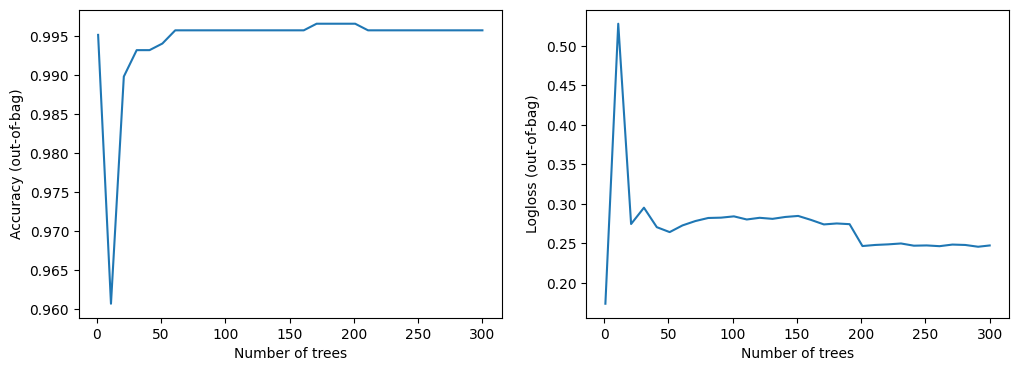

In [26]:
import matplotlib.pyplot as plt

logs = initial_model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")

plt.show()